# Hierarchical Clustering of Ethics-Based Requirements

This notebook reproduces the hierarchical clustering analysis used to explore how ethics-based requirements co-occur across the selected literature.

The workflow is:

1. Load the open-coding matrix.
2. Convert concept occurrences into a binary matrix.
3. Compute concept occurrence counts and the concept co-occurrence matrix.
4. Apply average-linkage hierarchical clustering.
5. Assign concepts to clusters.
6. Generate the occurrence plot and dendrogram.

The input is expected to follow the structure of the open-coding matrix: the first row contains concept names, the first column identifies studies, and non-empty cells indicate that a concept occurs in a study.


## 1. Setup

Paths are relative to the `analysis/` directory of the replication package. The notebook supports both Excel and CSV input files. By default, it reads the first sheet of `../coding/coding-matrices.xlsx`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

INPUT_PATH = Path("../coding/coding-matrices.xlsx")
SHEET_NAME = 0
N_CLUSTERS = 4

RESULTS_DIR = Path("../results")
FIGURES_DIR = RESULTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load the open-coding matrix


In [2]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Input file not found: {INPUT_PATH.resolve()}\n"
        "Update INPUT_PATH so that it points to the open-coding matrix."
    )

suffix = INPUT_PATH.suffix.lower()

if suffix == ".csv":
    df_raw = pd.read_csv(INPUT_PATH, header=None)
elif suffix in {".xlsx", ".xls"}:
    df_raw = pd.read_excel(INPUT_PATH, sheet_name=SHEET_NAME, header=None)
else:
    raise ValueError(
        f"Unsupported input format: {suffix}. Use a CSV or Excel file."
    )

df_raw.head()


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,NaN,Source,Article title,Concepts,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,Ethics,Privacy,Security,Safety,Responsibility,Transparency,Sustainability,Regulation,Fairness,Beneficence,Awareness,Accountability,Trust,Reliability,Equality,Autonomy,Dignity
2,1.0,Agbese 2021,Governance of Ethical and Trustworthy Al Syste...,x,x,x,x,NaN,x,x,NaN,x,NaN,NaN,x,NaN,x,NaN,NaN,NaN
3,2.0,Amaral 2021,Trustworthiness Requirements: The Pix Case Study,NaN,NaN,x,NaN,NaN,x,NaN,NaN,NaN,NaN,NaN,NaN,x,NaN,NaN,NaN,NaN
4,3.0,Ambritta 2024,Explainable AI for Human-Centric Ethical IoT S...,x,NaN,x,NaN,NaN,x,NaN,x,x,NaN,NaN,NaN,x,NaN,NaN,NaN,NaN


## 3. Build the binary concept matrix

The first row contains concept names. For each study, a non-empty cell is interpreted as the presence of the corresponding concept (`1`), while an empty cell is interpreted as absence (`0`).


In [3]:
# Concept names are stored in the second row.
# The first three columns contain study metadata:
# ID, Source, and Article title.

concept_header = df_raw.iloc[1, 3:]

# Keep only columns that contain concept names
valid_concepts = concept_header.notna()

concept_names = (
    concept_header.loc[valid_concepts]
    .astype(str)
    .str.strip()
    .tolist()
)

# Study data starts from the third row
concept_data = df_raw.iloc[2:, 3:].loc[:, valid_concepts].copy()
concept_data.columns = concept_names

# Convert concept occurrences to a binary representation
binary_matrix = concept_data.notna().astype(int)

# Exclude the umbrella category "Ethics" from all analyses
binary_matrix = binary_matrix.drop(columns=["Ethics"], errors="ignore")

print(f"Studies: {binary_matrix.shape[0]}")
print(f"Requirements: {binary_matrix.shape[1]}")
print(binary_matrix.columns.tolist())

binary_matrix.head()

Studies: 58
Requirements: 16
['Privacy', 'Security', 'Safety', 'Responsibility', 'Transparency', 'Sustainability', 'Regulation', 'Fairness', 'Beneficence', 'Awareness', 'Accountability', 'Trust', 'Reliability', 'Equality', 'Autonomy', 'Dignity']


,Privacy,Security,Safety,Responsibility,Transparency,Sustainability,Regulation,Fairness,Beneficence,Awareness,Accountability,Trust,Reliability,Equality,Autonomy,Dignity
2,1,1,1,0,1,1,0,1,0,0,1,0,1,0,0,0
3,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,1,0,0,1,0,1,1,0,0,0,1,0,0,0,0
5,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
6,1,0,0,1,1,1,0,1,1,0,0,1,0,0,1,1


## 4. Concept occurrence counts

The following plot shows how many selected studies contain each identified concept.


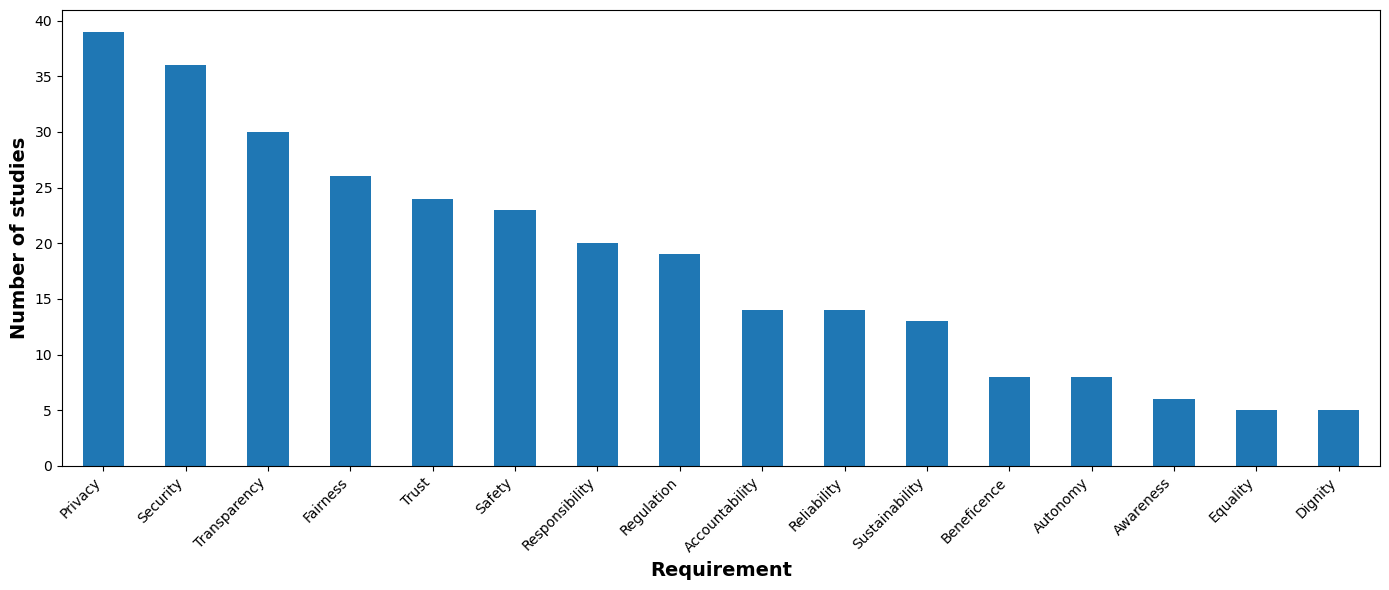

Saved: ../results/figures/requirement-occurrences.pdf


In [4]:
counts = (
    binary_matrix
    .sum(axis=0)
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))

counts.plot(kind="bar")

plt.xlabel("Requirement", fontsize=14, fontweight="bold")
plt.ylabel("Number of studies", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=10)

plt.tight_layout()

occurrence_figure = FIGURES_DIR / "requirement-occurrences.pdf"
plt.savefig(occurrence_figure, bbox_inches="tight")

plt.show()

print(f"Saved: {occurrence_figure}")

## 5. Concept co-occurrence matrix

The co-occurrence matrix counts how many selected studies contain each pair of concepts.


In [5]:
co_occurrence = binary_matrix.T.dot(binary_matrix)
co_occurrence


,Privacy,Security,Safety,Responsibility,Transparency,Sustainability,Regulation,Fairness,Beneficence,Awareness,Accountability,Trust,Reliability,Equality,Autonomy,Dignity
Privacy,39,27,17,14,22,10,14,18,7,4,9,16,10,5,6,5
Security,27,36,17,13,18,9,15,16,4,4,6,15,10,3,3,3
Safety,17,17,23,10,13,6,10,12,3,3,7,10,10,2,2,1
Responsibility,14,13,10,20,12,8,9,10,4,4,8,10,3,2,4,4
Transparency,22,18,13,12,30,8,10,19,5,5,11,15,8,5,5,5
Sustainability,10,9,6,8,8,13,6,8,4,3,5,4,3,2,4,4
Regulation,14,15,10,9,10,6,19,12,5,3,4,7,5,1,2,2
Fairness,18,16,12,10,19,8,12,26,6,4,8,14,10,2,4,3
Beneficence,7,4,3,4,5,4,5,6,8,2,2,5,2,1,5,3
Awareness,4,4,3,4,5,3,3,4,2,6,3,3,2,1,2,2


## 6. Hierarchical clustering

Hierarchical clustering is performed on the rows of the co-occurrence matrix using average linkage. This preserves the clustering procedure of the original analysis.


In [6]:
linked = linkage(co_occurrence.to_numpy(), method="average")

cluster_labels = fcluster(
    linked,
    t=N_CLUSTERS,
    criterion="maxclust",
)

hierarchical_clusters = (
    pd.DataFrame({
        "Concept": co_occurrence.index,
        "Cluster": cluster_labels,
    })
    .sort_values(["Cluster", "Concept"])
    .reset_index(drop=True)
)

cluster_output = RESULTS_DIR / "hierarchical-clusters.csv"
hierarchical_clusters.to_csv(cluster_output, index=False)

hierarchical_clusters


,Concept,Cluster
0,Accountability,1
1,Autonomy,1
2,Awareness,1
3,Beneficence,1
4,Dignity,1
5,Equality,1
6,Reliability,1
7,Sustainability,1
8,Privacy,2
9,Security,2


## 7. Dendrogram

The dendrogram visualizes the hierarchical relationships among the concepts based on their co-occurrence profiles.


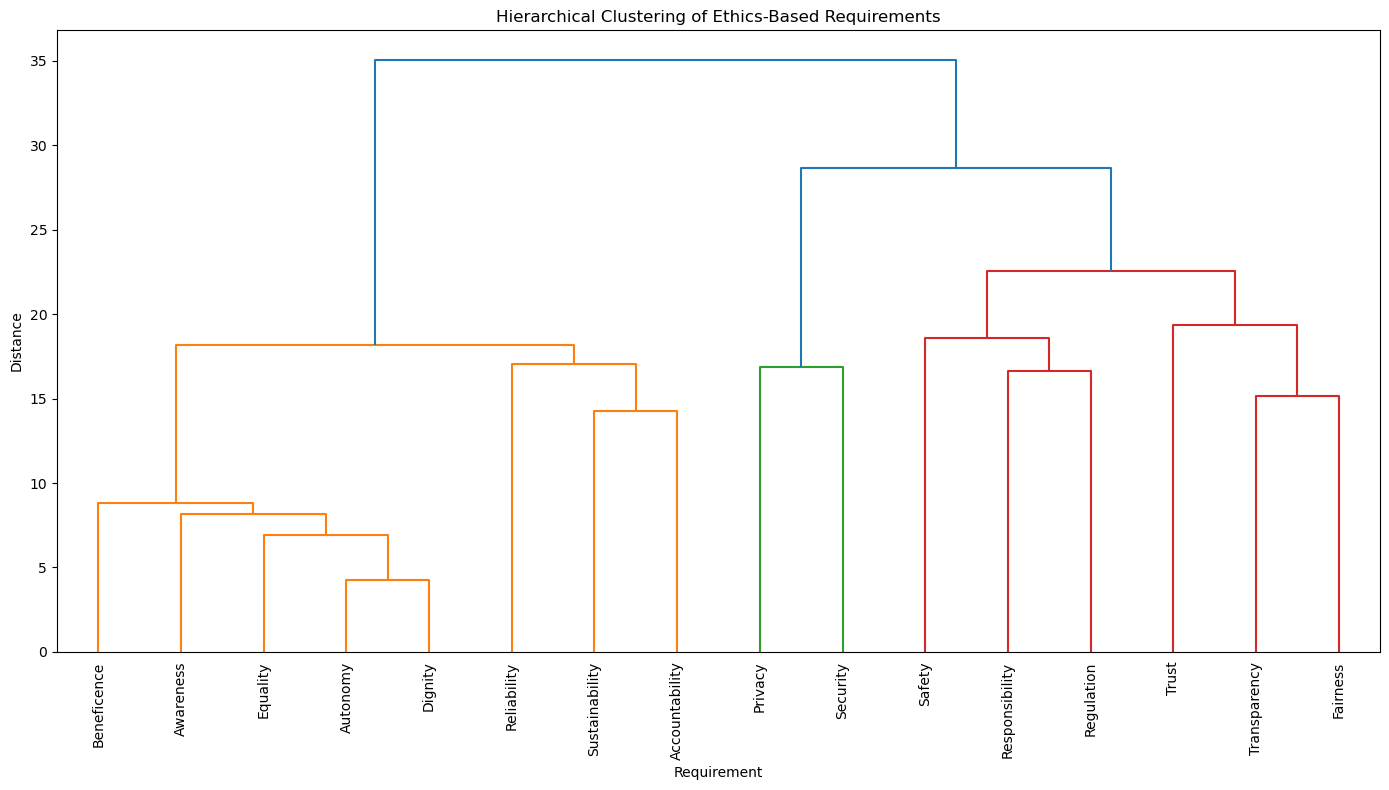

Saved: ../results/figures/hierarchical-clustering-dendrogram.pdf
Saved: ../results/hierarchical-clusters.csv


In [7]:
plt.figure(figsize=(14, 8))
dendrogram(
    linked,
    labels=co_occurrence.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=10,
)
plt.title("Hierarchical Clustering of Ethics-Based Requirements")
plt.xlabel("Requirement")
plt.ylabel("Distance")
plt.tight_layout()

dendrogram_figure = FIGURES_DIR / "hierarchical-clustering-dendrogram.pdf"
plt.savefig(dendrogram_figure, bbox_inches="tight")
plt.show()

print(f"Saved: {dendrogram_figure}")
print(f"Saved: {cluster_output}")
